<a href="https://colab.research.google.com/github/shreyoshi2304/Attention/blob/main/variability_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baseline Fano: 0.9583892261001516
Attention Fano: 1.01372852233677


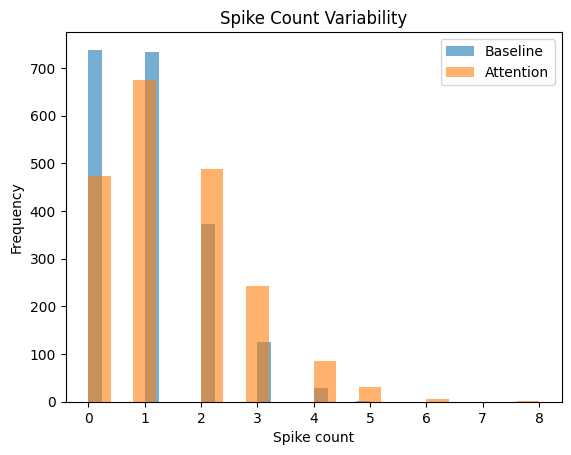

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Time
T = 2.0
dt = 0.001
t = np.arange(0, T, dt)

# Poisson spike generator
def generate_spikes(rate):
    return np.random.rand(len(t)) < rate * dt

# Compute Fano factor
def fano_factor(spike_counts):
    return np.var(spike_counts) / np.mean(spike_counts)

# Trials
n_trials = 50
window = 50  # ms window for counting

def run_condition(gain=1.0):
    spike_counts = []

    for _ in range(n_trials):
        base_rate = 20  # Hz
        rate = gain * base_rate

        spikes = generate_spikes(rate)

        # binning
        bins = np.add.reduceat(spikes, np.arange(0, len(spikes), window))
        spike_counts.extend(bins)

    return np.array(spike_counts)

# Baseline vs attention
baseline_counts = run_condition(gain=1.0)
attention_counts = run_condition(gain=1.5)

# Fano factors
fano_baseline = fano_factor(baseline_counts)
fano_attention = fano_factor(attention_counts)

print("Baseline Fano:", fano_baseline)
print("Attention Fano:", fano_attention)

# Plot distributions
plt.figure()
plt.hist(baseline_counts, bins=20, alpha=0.6, label="Baseline")
plt.hist(attention_counts, bins=20, alpha=0.6, label="Attention")
plt.legend()
plt.title("Spike Count Variability")
plt.xlabel("Spike count")
plt.ylabel("Frequency")
plt.show()